In [1]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [2]:
import os
import sys

# ============================================================================
# CONFIGURACIÓN DE DIRECTORIOS
# ============================================================================

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    project_dir = '/content/TFMDS'
    os.chdir(project_dir)
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        project_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(project_dir)

# Agregar el directorio del proyecto al path de Python
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("Directorio de trabajo:", os.getcwd())
print("Python path incluye proyecto:", os.getcwd() in sys.path)

Directorio de trabajo: /workspaces/TFMDS
Python path incluye proyecto: True


In [3]:
# ============================================================================
# IMPORTACIONES BASE Y VERSIÓN
# ============================================================================
import os, sys
import pandas as pd
import numpy as np
import time

import torch
import pytorch_lightning as pl
from neuralforecast import NeuralForecast, __version__ as nf_version
from neuralforecast.models import DeepAR
from neuralforecast.losses.pytorch import MAE

# Importar utilidades desde la carpeta 'lib' evitando el paquete
lib_dir = os.path.join(os.getcwd(), 'lib')
if lib_dir not in sys.path:
    sys.path.insert(0, lib_dir)

from lib.dl_utils import (
    preparar_datos_neuralforecast,
    seleccionar_features_exogenas,
    reconstruir_predicciones,
    preparar_variables_estaticas,
)
from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error, resumen_final_modelos
from lib.graficos_dl import (
    grafico_prediccion_diaria_agregada,
    grafico_prediccion_por_cluster,
    grafico_productos_por_cluster,
    dashboard_metricas_dl,
    dashboard_prediccion_dl
)

print(f"torch: {torch.__version__}")
print(f"pytorch_lightning: {pl.__version__}")
print(f"neuralforecast: {nf_version}")

torch: 2.9.1+cu128
pytorch_lightning: 2.6.0
neuralforecast: 3.1.2


# Lectura de datos preparados para Deep Learning

In [4]:
# ============================================================================
# LECTURA DE DATOS
# ============================================================================

print("\n" + "="*100)
print("📂 CARGANDO DATOS PARA DEEP LEARNING")
print("="*100)

# Datos normalizados para entrenamiento
df_train_raw = pd.read_csv('datos/df_train_dl.csv', sep=';', parse_dates=['idSecuencia'])
df_test_raw = pd.read_csv('datos/df_test_dl.csv', sep=';', parse_dates=['idSecuencia'])

print(f"\nDatos cargados:")
print(f"\nColumnas: {list(df_train_raw.columns)}")
print(f"   Train: {df_train_raw.shape}")
print(f"   Test:  {df_test_raw.shape}")


📂 CARGANDO DATOS PARA DEEP LEARNING

Datos cargados:

Columnas: ['idSecuencia', 'producto', 'udsVenta', 'bolPromocion', 'bolOpen', 'bolHoliday', 'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos', 'Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Train: (625800, 26)
   Test:  (27714, 26)

Datos cargados:

Columnas: ['idSecuencia', 'producto', 'udsVenta', 'bolPromocion', 'bolOpen', 'bolHoliday', 'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos', 'Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Train: (625800, 26)
   Test:  (27714, 26)


# Preparación de datos para NeuralForecast

In [5]:
# ============================================================================
# PREPARACIÓN DE DATOS PARA NEURALFORECAST
# ============================================================================

print("\n" + "="*100)
print("🔧 PREPARANDO DATOS PARA NEURALFORECAST")
print("="*100)

# Convertir al formato NeuralForecast (unique_id, ds, y)
df_train_nf, df_test_nf = preparar_datos_neuralforecast(
    df_train_raw,
    df_test_raw,
    col_fecha='idSecuencia',
    col_producto='producto',
    col_target='udsVenta'
)

print(f"\n📋 Columnas: {list(df_train_nf.columns)}")
print(f"   Train: {df_train_nf.shape}")
print(f"   Test:  {df_test_nf.shape}")


🔧 PREPARANDO DATOS PARA NEURALFORECAST

📋 Columnas: ['ds', 'unique_id', 'y', 'bolPromocion', 'bolOpen', 'bolHoliday', 'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos', 'Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Train: (625800, 26)
   Test:  (27714, 26)

📋 Columnas: ['ds', 'unique_id', 'y', 'bolPromocion', 'bolOpen', 'bolHoliday', 'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos', 'Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Train: (625800, 26)
   Test:  (27714, 26)


# Configuración del modelo DeepAR

El algoritmo **DeepAR** es un método de pronóstico de última generación desarrollado por **Amazon**. Se distingue por ser una **técnica de pronóstico probabilístico**, ya que no predice un valor único, sino que genera una **distribución de probabilidad** de los valores futuros. Este enfoque permite la estimación de la **incertidumbre** y la provisión de **intervalos de confianza** para las predicciones.

DeepAR se basa en una arquitectura de **red neuronal recurrente autorregresiva (RNN)**. El modelo es altamente eficaz para modelar **series temporales complejas** con estacionalidad, tendencias e irregularidades. Su diseño le permite **aprender de manera eficiente** del comportamiento histórico de **múltiples series temporales relacionadas** simultáneamente. Para su entrada, el modelo utiliza la **longitud del contexto** (*lags*) junto con la inclusión de **covariables estáticas y futuras** (*static and future exogenous columns*).

## Preparar característias estáticas

In [6]:
# ============================================================================
# PREPARAR VARIABLES ESTÁTICAS
# ============================================================================

print("\n" + "="*100)
print("🔧 PREPARANDO VARIABLES ESTÁTICAS")
print("="*100)

# Definir columnas estáticas (que no varían en el tiempo)
stat_exog_list = ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']

# Separar variables estáticas en DataFrame aparte
df_train_nf, df_test_nf, static_df = preparar_variables_estaticas(
    df_train_nf,
    df_test_nf,
    stat_exog_list
)

print(f"\n📋 Columnas df_train_nf: {list(df_train_nf.columns)}")


🔧 PREPARANDO VARIABLES ESTÁTICAS

✅ Variables estáticas extraídas:
   Columnas estáticas: ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Shape static_df: (894, 5)
   Productos únicos: 894

📊 Datasets temporales actualizados:
   Train: (625800, 22) (eliminadas 4 columnas)
   Test:  (27714, 22) (eliminadas 4 columnas)

📋 Columnas df_train_nf: ['ds', 'unique_id', 'y', 'bolPromocion', 'bolOpen', 'bolHoliday', 'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos']


## Preparar características históricas

In [7]:
# =============================================================================
# LIMPIEZA DE FEATURES HISTÓRICAS (evitar NaN al inicio del test)
# =============================================================================

print("\n" + "="*100)
print("🧹 LIMPIANDO FEATURES HISTÓRICAS (hist_exog_list)")
print("="*100)

# Definir la lista de features históricas que usa el modelo
hist_exog_list = [
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

# Comprobar existencia de columnas
def _check_missing(df, cols):
    return [c for c in cols if c not in df.columns]

missing_train = _check_missing(df_train_nf, hist_exog_list)
missing_test = _check_missing(df_test_nf, hist_exog_list)

if missing_train:
    print(f"⚠️ Faltan columnas en train: {missing_train}")
if missing_test:
    print(f"⚠️ Faltan columnas en test: {missing_test}")

cols_ok = [c for c in hist_exog_list if c in df_train_nf.columns and c in df_test_nf.columns]

if cols_ok:
    # Estadísticas antes
    na_train_before = int(df_train_nf[cols_ok].isna().sum().sum())
    na_test_before = int(df_test_nf[cols_ok].isna().sum().sum())

    # Forward fill por serie (unique_id) y rellenar remanentes al inicio con 0
    df_train_nf[cols_ok] = (
        df_train_nf.groupby('unique_id', observed=True)[cols_ok]
        .ffill()
        .fillna(0)
    )
    df_test_nf[cols_ok] = (
        df_test_nf.groupby('unique_id', observed=True)[cols_ok]
        .ffill()
        .fillna(0)
    )

    # Asegurar tipos numéricos (por si hubiera strings)
    for df_tmp in (df_train_nf, df_test_nf):
        for c in cols_ok:
            df_tmp[c] = pd.to_numeric(df_tmp[c], errors='coerce').fillna(0)

    # Estadísticas después
    na_train_after = int(df_train_nf[cols_ok].isna().sum().sum())
    na_test_after = int(df_test_nf[cols_ok].isna().sum().sum())

    print(f"✅ NaNs en train: {na_train_before} → {na_train_after}")
    print(f"✅ NaNs en test:  {na_test_before} → {na_test_after}")
else:
    print("⚠️ No hay columnas históricas válidas para limpiar.")

print("\n" + "="*100)
print(f"Features históricas {hist_exog_list}")


🧹 LIMPIANDO FEATURES HISTÓRICAS (hist_exog_list)
✅ NaNs en train: 3 → 0
✅ NaNs en test:  0 → 0

Features históricas ['lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA']
✅ NaNs en train: 3 → 0
✅ NaNs en test:  0 → 0

Features históricas ['lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4', 'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA']


## Preparar características futuras

In [8]:
# FEATURES FUTURAS

futr_exog_list=[
        'bolOpen', 'bolHoliday', 'bolPromocion',
        'dia_semana_sin', 'dia_semana_cos',
        'mes_sin', 'mes_cos',
        'semana_sin', 'semana_cos'
    ]

print("\n" + "="*100)
print(f"Features futuras {futr_exog_list}")


Features futuras ['bolOpen', 'bolHoliday', 'bolPromocion', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos']


## Configuración del modelo

In [12]:
# ============================================================================
# CONFIGURACIÓN DEL MODELO DEEPAR
# ============================================================================

print("\n" + "="*100)
print("🧠 CONFIGURANDO MODELO DEEPAR")
print("="*100)

# Horizonte de predicción (30 días)
HORIZON = 31

# Hiperparámetros del modelo DeepAR
modelo_deepar = DeepAR(
    h=HORIZON,                      # Horizonte de predicción
    input_size=60,                  # Ventana de entrada (últimos 60 días)
    lstm_hidden_size=128,           # Tamaño capa oculta DEEPAR
    lstm_n_layers=2,                # Número de capas DEEPAR
    lstm_dropout=0.1,               # Dropout en DEEPAR
    decoder_hidden_layers=2,        # Capas adicionales en decoder
    decoder_hidden_size=64,         # Tamaño de capas decoder
    trajectory_samples=100,         # Número de trayectorias para predicción probabilística
    
    # Variables exógenas (DeepAR solo soporta futuras y estáticas, NO históricas)
    futr_exog_list=futr_exog_list,
    # hist_exog_list=hist_exog_list,  # DeepAR NO soporta variables históricas
    stat_exog_list=stat_exog_list,  # Variables estáticas (clusters)
    
    # Configuración de entrenamiento
    valid_loss=MAE(),               # Métrica de validación
    max_steps=500,                  # Número máximo de pasos de entrenamiento
    learning_rate=1e-3,             # Learning rate
    scaler_type='standard',         # Escalado
    batch_size=32,                  # Batch size
    random_seed=42                  # Semilla aleatoria
)

print("\n✅ Modelo DeepAR configurado:")
print(f"   Horizonte: {HORIZON} días")
print(f"   Input size: {60} días")
print(f"   DEEPAR hidden size: {128}")
print(f"   DEEPAR layers: {2}")
print(f"   Trajectory samples: {100}")
print(f"   Max steps: {500}")
print("\n⚠️ NOTA: DeepAR genera predicciones probabilísticas.")
print("   La predicción final es la media de las trayectorias muestreadas.")
print("\n⚠️ LIMITACIÓN: DeepAR NO soporta variables históricas (hist_exog_list).")
print("   Solo admite variables futuras y estáticas.")

Seed set to 42



🧠 CONFIGURANDO MODELO DEEPAR

✅ Modelo DeepAR configurado:
   Horizonte: 31 días
   Input size: 60 días
   DEEPAR hidden size: 128
   DEEPAR layers: 2
   Trajectory samples: 100
   Max steps: 500

⚠️ NOTA: DeepAR genera predicciones probabilísticas.
   La predicción final es la media de las trayectorias muestreadas.

⚠️ LIMITACIÓN: DeepAR NO soporta variables históricas (hist_exog_list).
   Solo admite variables futuras y estáticas.


# Entrenamiento del modelo

In [13]:
# ============================================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================================

print("\n" + "="*100)
print("🚀 INICIANDO ENTRENAMIENTO DEEPAR")
print("="*100)

# Crear instancia de NeuralForecast
nf = NeuralForecast(
    models=[modelo_deepar],
    freq='D'  # Frecuencia diaria
)

# Entrenar el modelo
print("\n⏳ Entrenando modelo DEEPAR...")
start_time = time.perf_counter()

nf.fit(df=df_train_nf, static_df=static_df)

elapsed = time.perf_counter() - start_time
print(f"\n✅ Entrenamiento completado en {elapsed:.2f} segundos ({elapsed/60:.2f} minutos)")


🚀 INICIANDO ENTRENAMIENTO DEEPAR

⏳ Entrenando modelo DEEPAR...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores

  | Name         | Type             | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss         | DistributionLoss | 5      | train | 0    
1 | valid_loss   | MAE              | 0      | train | 0    
2 | padder_train | ConstantPad1d    | 0      | train | 0    
3 | scaler       | TemporalNorm     | 0      | train | 0    
4 | hist_encoder | LSTM             | 205 K  | train | 0    
5 | decoder      | Decoder          | 8.5 K  | train | 0    
------------------------------------------------------------------
214 K     Trainable params
5         Non-trainable params
214 K     Total params
0.857     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0         Total Flops

  | Name         | Type             | Params | Mode  | FLOPs
---------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.



✅ Entrenamiento completado en 623.51 segundos (10.39 minutos)


# DEEPAR Global

In [14]:
# ============================================================================
# PREDICCIÓN
# ============================================================================

print("\n" + "="*100)
print("🔮 GENERANDO PREDICCIONES")
print("="*100)

# Realizar predicciones
print("\n⏳ Generando predicciones en test set...")
start_time = time.perf_counter()

y_hat = nf.predict(futr_df=df_test_nf)

elapsed = time.perf_counter() - start_time

print(f"\n✅ Predicciones generadas en {elapsed:.2f} segundos")
print(f"   Shape predicciones: {y_hat.shape}")
print(f"\n📋 Primeras predicciones:")
print(y_hat.head())

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores



🔮 GENERANDO PREDICCIONES

⏳ Generando predicciones en test set...


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Predicciones generadas en 2.03 segundos
   Shape predicciones: (27714, 8)

📋 Primeras predicciones:
   unique_id         ds    DeepAR  DeepAR-median  DeepAR-lo-90  DeepAR-lo-80  \
0          1 2024-10-06 -0.766917      -0.750964     -2.559586     -1.847003   
1          1 2024-10-07  6.559080       7.546132      0.970067      2.207813   
2          1 2024-10-08  6.729376       6.782844     -2.504865      0.158733   
3          1 2024-10-09  6.741586       5.738985     -2.837215      0.057941   
4          1 2024-10-10  6.782306       6.546578      1.025643      2.291920   

   DeepAR-hi-80  DeepAR-hi-90  
0      0.531162      0.986471  
1     13.373633     14.578025  
2     13.325606     14.425380  
3     13.868807     16.813093  
4     12.455872     14.531791  


# Reconstruir predicciones en formato original

In [15]:
def preparar_predicciones_test(y_hat, df_test_nf):
    """
    Prepara las predicciones en formato NeuralForecast para métricas y gráficos.
    
    Parameters
    ----------
    y_hat : pd.DataFrame
        DataFrame con predicciones del modelo. Debe contener 'unique_id', 'ds' 
        y columna de predicción (ej: 'DEEPAR', 'prediccion', etc.)
    df_test_nf : pd.DataFrame
        DataFrame de test en formato NeuralForecast con columnas 'unique_id', 
        'ds', 'y', 'bolOpen'
    
    Returns
    -------
    pd.DataFrame
        Dataset con predicciones procesadas, incluyendo errores calculados
    """
    print("\n" + "="*100)
    print("🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS")
    print("="*100)
    
    # y_hat puede venir con 'unique_id' como índice; normalizamos para merge
    if y_hat.index.name == 'unique_id':
        y_hat = y_hat.reset_index()
    
    # Asegurar que existen columnas necesarias
    required_cols_pred = {'unique_id', 'ds'}
    if not required_cols_pred.issubset(set(y_hat.columns)):
        raise ValueError(f"Faltan columnas en y_hat para merge: {required_cols_pred - set(y_hat.columns)}")
    
    # Renombrar columna del modelo a 'prediccion' sin copiar innecesariamente
    if 'DEEPAR' in y_hat.columns:
        y_hat = y_hat.rename(columns={'DEEPAR': 'prediccion'})
    elif 'prediccion' not in y_hat.columns:
        # Si el modelo cambió el nombre, tomamos la primera columna de predicción distinta a ['unique_id','ds']
        pred_cols = [c for c in y_hat.columns if c not in ['unique_id', 'ds']]
        if not pred_cols:
            raise ValueError("No se encontró columna de predicción en y_hat.")
        y_hat = y_hat.rename(columns={pred_cols[0]: 'prediccion'})
    
    # Merge con el test en formato NF (evitando copias)
    df_test_pred = df_test_nf[['unique_id', 'ds', 'y', 'bolOpen']].merge(
        y_hat[['unique_id', 'ds', 'prediccion']],
        on=['unique_id', 'ds'],
        how='left'
    )
    
    # Columnas compatibles con funciones de gráficos existentes
    df_test_pred['idSecuencia'] = df_test_pred['ds']
    df_test_pred['producto'] = df_test_pred['unique_id']
    # Mantener convención 'udsVenta' para métricas existentes
    df_test_pred['udsVenta'] = df_test_pred['y']
    
    # Si df_test_pred la columna prediccion es menor que cero pone un cero
    df_test_pred['prediccion'] = df_test_pred['prediccion'].clip(lower=0)
    
    # Eliminar días que la tienda está cerrada
    df_test_pred = df_test_pred[df_test_pred['bolOpen'] == 1].copy()
    
    # Calcular errores en escala original
    df_test_pred['error'] = df_test_pred['prediccion'] - df_test_pred['udsVenta']
    df_test_pred['error_abs'] = np.abs(df_test_pred['error'])
    
    # print(f"\n✅ Dataset de predicciones listo (sin reconstrucción ni desnormalización):")
    # print(f"   Shape: {df_test_pred.shape}")
    # print(f"   Predicciones no nulas: {df_test_pred['prediccion'].notna().sum()}")
    # print(f"\n📊 Estadísticas básicas del error (escala original):")
    # print(f"   Error medio: {df_test_pred['error'].mean():.2f} unidades")
    # print(f"   Error std: {df_test_pred['error'].std():.2f} unidades")
    # print(f"   Error abs medio: {df_test_pred['error_abs'].mean():.2f} unidades")
    
    return df_test_pred

In [16]:
df_test_pred = preparar_predicciones_test (y_hat, df_test_nf)


🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS


# Reconstruir columna Cluster desde one-hot encoding

In [17]:
# ============================================================================
# RECONSTRUIR COLUMNA CLUSTER DESDE static_df (one-hot estático)
# ============================================================================

# Si ya existe 'Cluster' en el dataset de predicciones, la respetamos
if 'Cluster' in df_test_pred.columns:
    try:
        df_test_pred['Cluster'] = df_test_pred['Cluster'].astype('Int64')
    except Exception:
        pass
    print("\n✅ Columna 'Cluster' ya presente en df_test_pred.")
    print("   Distribución:")
    print(df_test_pred['Cluster'].value_counts(dropna=False).sort_index())
else:
    # Intentar reconstruir desde static_df (variables estáticas por unique_id)
    cluster_cols = [c for c in static_df.columns if c.startswith('Cluster_')]

    if cluster_cols:
        # Ordenar columnas y calcular argmax por unique_id
        cluster_cols = sorted(cluster_cols, key=lambda x: int(x.split('_')[1]))
        static_map = static_df[['unique_id'] + cluster_cols].copy()
        cluster_idx = static_map[cluster_cols].to_numpy().argmax(axis=1)
        static_map['Cluster'] = cluster_idx

        # Unir al dataset de predicciones
        df_test_pred = df_test_pred.merge(
            static_map[['unique_id', 'Cluster']],
            on='unique_id',
            how='left'
        )

        print(f"\n✅ 'Cluster' reconstruido desde static_df ({len(cluster_cols)} columnas one-hot).")
        print("   Distribución:")
        print(df_test_pred['Cluster'].value_counts(dropna=False).sort_index())
    else:
        print("\n⚠️ No se encontraron columnas 'Cluster_*' en static_df.")
        print("   Las visualizaciones por cluster no estarán disponibles.")


✅ 'Cluster' reconstruido desde static_df (4 columnas one-hot).
   Distribución:
Cluster
0     7826
1     2756
2      416
3    12246
Name: count, dtype: int64


# Métricas y gráficos DEEPAR Global

## Métricas

In [18]:
from lib.utils import obtener_top_productos_por_cluster

# ============================================================================
# CÁLCULO DE MÉTRICAS
# ============================================================================

print("\n" + "="*100)
print("📊 CÁLCULO DE MÉTRICAS")
print("="*100)

# Filtrar valores válidos (sin NaN)
df_valid = df_test_pred.dropna(subset=['prediccion', 'udsVenta'])

# Calcular métricas
metricas_deepar = calcular_metricas(
    y=df_valid['udsVenta'],
    y_pred=df_valid['prediccion'],
    algoritmo='DEEPAR',
    ndetalle= 'Global',
    cluster=None,
    producto=None
)

# Mostrar resumen
print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_deepar])

# Guardar para comparación posterior
todas_metricas = [metricas_deepar]

# Calcular métricas por cluster y guardar
for cluster in df_test_pred['Cluster'].unique():
    y_test_pred_cl = df_test_pred.loc[df_test_pred['Cluster'] == cluster, ['prediccion']]
    y_test_cl = df_test_pred.loc[df_test_pred['Cluster'] == cluster, ['udsVenta']]
    metricas_cluster = calcular_metricas(
        y_test_cl, y_test_pred_cl,
        algoritmo='DEEPAR', ndetalle='Global', cluster= cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
# Construir columna Cluster en df_train_raw si no existe
if 'Cluster' not in df_train_raw.columns:
    if cluster_cols:
        cluster_idx_train = static_df[cluster_cols].to_numpy().argmax(axis=1)
        static_map_train = static_df[['unique_id']].copy()
        static_map_train['Cluster'] = cluster_idx_train
        df_train_raw = df_train_raw.merge(
            static_map_train[['unique_id', 'Cluster']],
            left_on='producto',
            right_on='unique_id',
            how='left'
        )
        df_train_raw.drop(columns=['unique_id'], inplace=True)
        print("\n✅ 'Cluster' añadido a df_train_raw desde static_df.")
    else:
        print("\n⚠️ No se pudo añadir 'Cluster' a df_train_raw (faltan columnas one-hot).")
    
# Calcular métricas por producto top en cada cluster
top_productos = obtener_top_productos_por_cluster(
    df=df_train_raw,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

for cluster, productos in top_productos.items():
    for producto in productos:
        idx_producto = (df_test_pred['Cluster'] == cluster) & (df_test_pred['producto'] == producto)
        y_test_prod = df_test_pred.loc[idx_producto, 'udsVenta']
        y_test_pred_prod = df_test_pred.loc[idx_producto, 'prediccion']
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='DEEPAR',
            ndetalle='Global', cluster=cluster, producto=producto) 
        todas_metricas.append(metricas_producto)

resumen_metricas(todas_metricas)    


📊 CÁLCULO DE MÉTRICAS

📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   DEEPAR   Global    None     None 1.4522 2.5863 0.1271     68.68     163.58 0.7926    88.94

🏆 Mejor modelo: DEEPAR (RMSE: 2.5863)

📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   DEEPAR   Global    None     None 1.4522 2.5863 0.1271     68.68     163.58 0.7926    88.94

🏆 Mejor modelo: DEEPAR (RMSE: 2.5863)

✅ 'Cluster' añadido a df_train_raw desde static_df.

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   DEEPAR   Global      3.0     314.0 0.1387  0.1464  0.0000       NaN     200.00    NaN      NaN
   DEEPAR   Global      3.0     257.0 0.5067  1.2466 -0.1710     98.99     199.13 0.8482   101.33
   DEEPAR   Global      3.0       NaN 0.8626 

## Dashboard

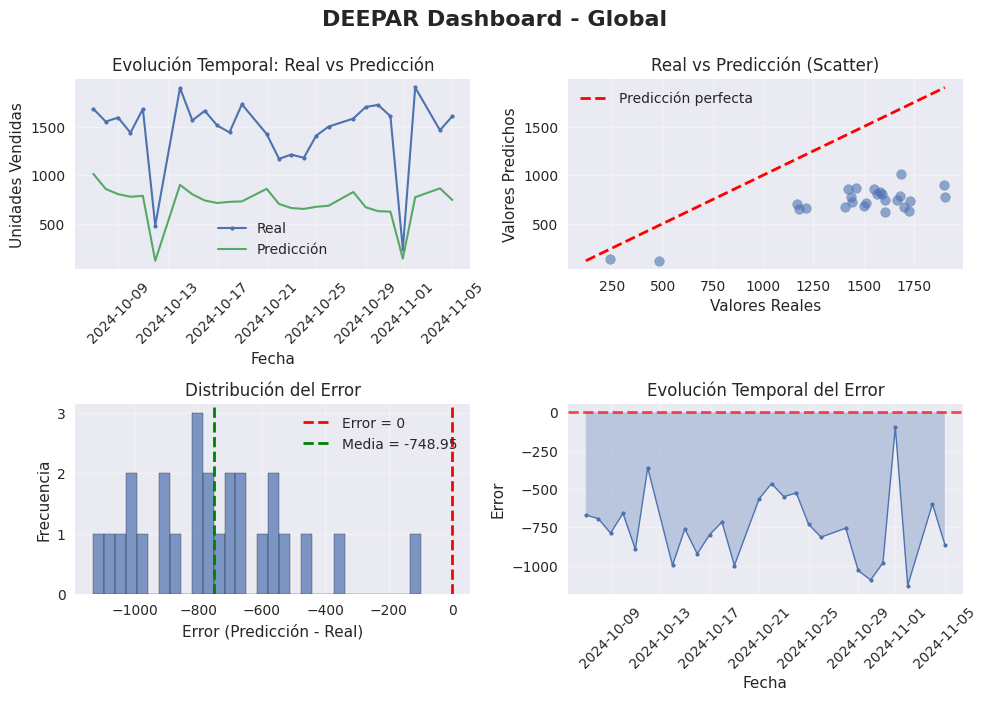

In [19]:
# Visualizaciones del modelo global
df_test_viz_sum = df_test_pred.groupby('idSecuencia')[['udsVenta', 'prediccion']].sum().reset_index()
df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum['udsVenta']

dashboard_prediccion_dl(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real='udsVenta',
        col_pred='prediccion',
        titulo_principal=f'DEEPAR Dashboard - Global',
        figsize=(10, 7)
        )

# DEEPAR por Cluster

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores

  | Name         | Type             | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss         | DistributionLoss | 5      | train | 0    
1 | valid_loss   | MAE              | 0      | train | 0    
2 | padder_train | ConstantPad1d    | 0      | train | 0    
3 | scaler       | TemporalNorm     | 0      | train | 0    
4 | hist_encoder | LSTM             | 205 K  | train | 0    
5 | decoder      | Decoder          | 8.5 K  | train | 0    
------------------------------------------------------------------
214 K     Trainable params
5         Non-trainable params
214 K     Total params
0.857     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0         Total Flops

  | Name         | Type             | Params | Mode  | FLOPs
---------------------------------------------

Procesando Cluster_0:
  - df_train_nf_c: 210700 filas
  - df_test_nf_c: 9331 filas

⏳ Entrenando modelo DEEPAR...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
GPU available: False, used: False
TPU available: False, using: 0 TPU cores



✅ Entrenamiento completado en 546.96 segundos (9.12 minutos)

⏳ Generando predicciones en test set...


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Predicciones generadas en 0.71 segundos

🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

📊 Métricas del Modelo para Cluster_0:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   DEEPAR  Cluster        0     None 1.7528 2.6989 0.0104     52.98      139.3 0.7758    90.78

🏆 Mejor modelo: DEEPAR (RMSE: 2.6989)


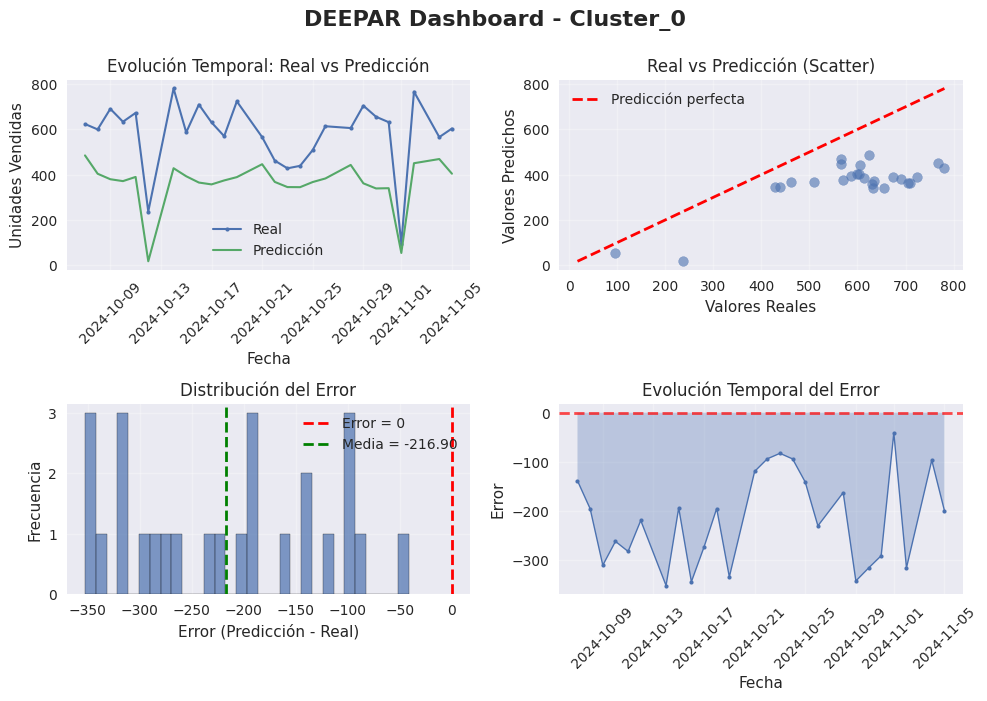

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores

  | Name         | Type             | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss         | DistributionLoss | 5      | train | 0    
1 | valid_loss   | MAE              | 0      | train | 0    
2 | padder_train | ConstantPad1d    | 0      | train | 0    
3 | scaler       | TemporalNorm     | 0      | train | 0    
4 | hist_encoder | LSTM             | 205 K  | train | 0    
5 | decoder      | Decoder          | 8.5 K  | train | 0    
------------------------------------------------------------------
214 K     Trainable params
5         Non-trainable params
214 K     Total params
0.857     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0         Total Flops

  | Name         | Type             | Params | Mode  | FLOPs
---------------------------------------------

Procesando Cluster_1:
  - df_train_nf_c: 74200 filas
  - df_test_nf_c: 3286 filas

⏳ Entrenando modelo DEEPAR...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
GPU available: False, used: False
TPU available: False, using: 0 TPU cores



✅ Entrenamiento completado en 535.87 segundos (8.93 minutos)

⏳ Generando predicciones en test set...


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Predicciones generadas en 0.29 segundos

🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

📊 Métricas del Modelo para Cluster_1:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   DEEPAR  Cluster        1     None 2.8014 3.7369 0.0712     54.56     103.25 0.7469    73.47

🏆 Mejor modelo: DEEPAR (RMSE: 3.7369)


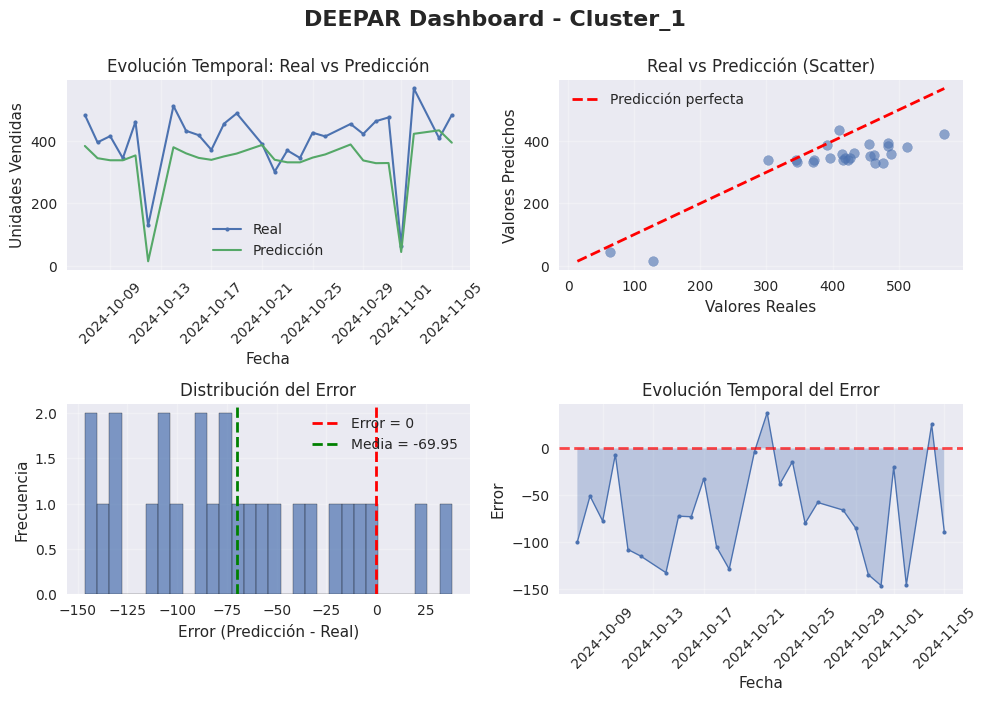

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name         | Type             | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss         | DistributionLoss | 5      | train | 0    
1 | valid_loss   | MAE              | 0      | train | 0    
2 | padder_train | ConstantPad1d    | 0      | train | 0    
3 | scaler       | TemporalNorm     | 0      | train | 0    
4 | hist_encoder | LSTM             | 205 K  | train | 0    
5 | decoder      | Decoder          | 8.5 K  | train | 0    
------------------------------------------------------------------
214 K     Trainable params
5         Non-trainable params
214 K     Total params
0.857     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0         Total Flops
TPU available: False, using: 0 TPU cores

  | Name         | Type             | Params | Mode  | FLOPs
---------------------------------------------

Procesando Cluster_2:
  - df_train_nf_c: 11200 filas
  - df_test_nf_c: 496 filas

⏳ Entrenando modelo DEEPAR...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
GPU available: False, used: False
TPU available: False, using: 0 TPU cores



✅ Entrenamiento completado en 522.55 segundos (8.71 minutos)

⏳ Generando predicciones en test set...


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Predicciones generadas en 0.11 segundos

🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

📊 Métricas del Modelo para Cluster_2:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   DEEPAR  Cluster        2     None 3.6417 5.3411 0.1184     67.29      83.58 0.7427    63.41

🏆 Mejor modelo: DEEPAR (RMSE: 5.3411)


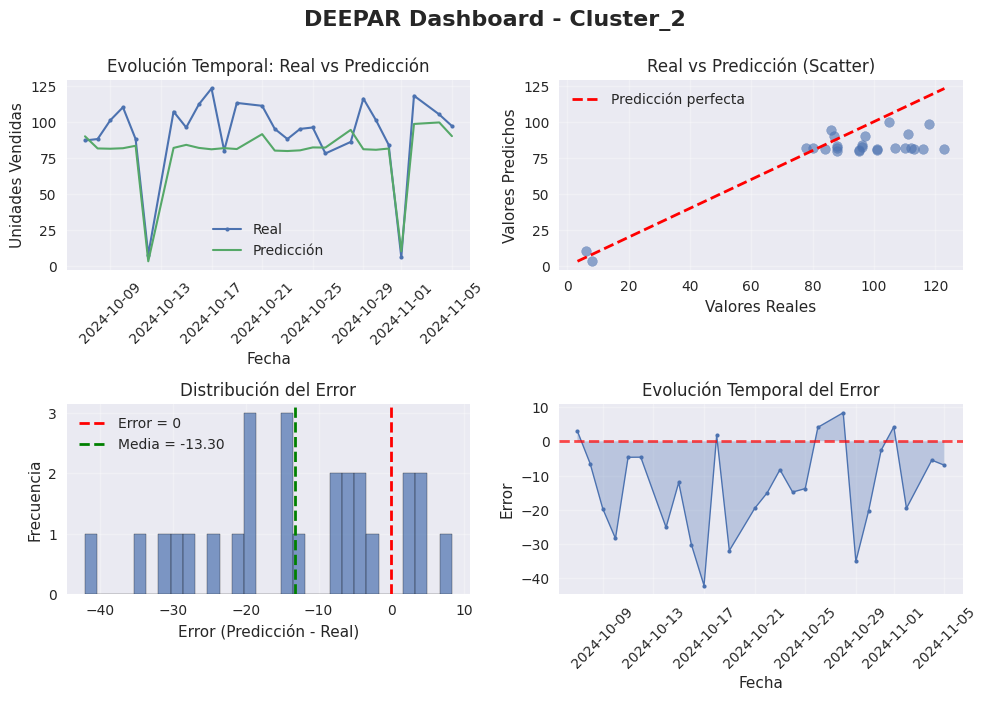

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name         | Type             | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss         | DistributionLoss | 5      | train | 0    
1 | valid_loss   | MAE              | 0      | train | 0    
2 | padder_train | ConstantPad1d    | 0      | train | 0    
3 | scaler       | TemporalNorm     | 0      | train | 0    
4 | hist_encoder | LSTM             | 205 K  | train | 0    
5 | decoder      | Decoder          | 8.5 K  | train | 0    
------------------------------------------------------------------
214 K     Trainable params
5         Non-trainable params
214 K     Total params
0.857     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0         Total Flops
TPU available: False, using: 0 TPU cores

  | Name         | Type             | Params | Mode  | FLOPs
---------------------------------------------

Procesando Cluster_3:
  - df_train_nf_c: 329700 filas
  - df_test_nf_c: 14601 filas

⏳ Entrenando modelo DEEPAR...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
GPU available: False, used: False
TPU available: False, using: 0 TPU cores



✅ Entrenamiento completado en 541.86 segundos (9.03 minutos)

⏳ Generando predicciones en test set...


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Predicciones generadas en 1.10 segundos

🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

📊 Métricas del Modelo para Cluster_3:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto   MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   DEEPAR  Cluster        3     None 0.852 1.7833 -0.0656     83.94     187.34 0.8002   104.91

🏆 Mejor modelo: DEEPAR (RMSE: 1.7833)


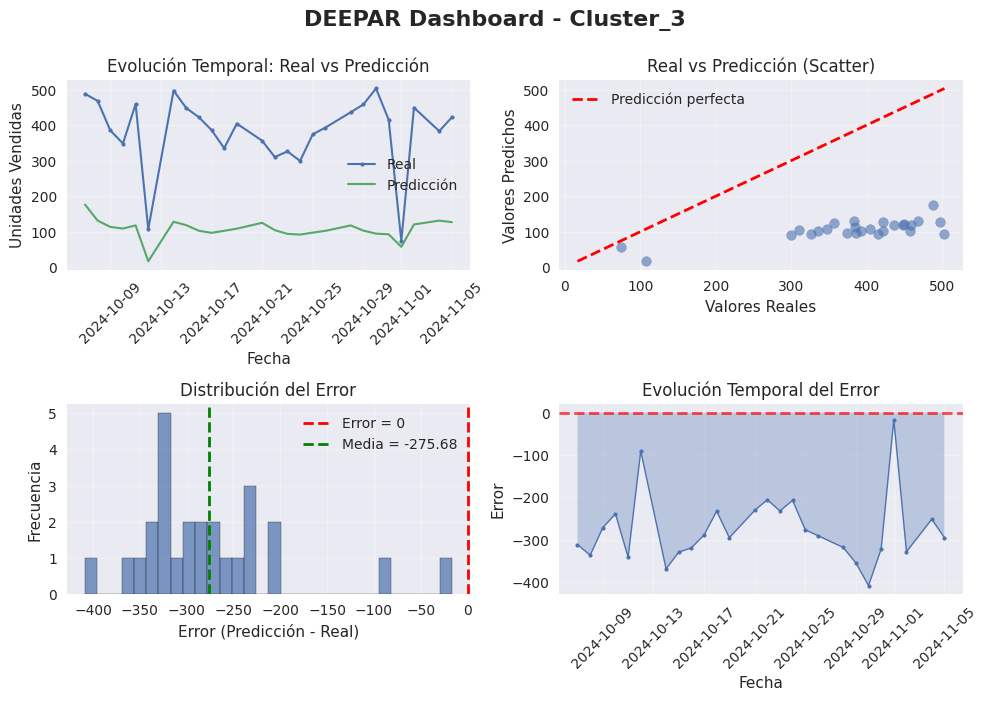

In [20]:
# Obtener las columnas que comienzan con 'Cluster_'
cluster_cols = [col for col in df_train_raw.columns if col.startswith('Cluster_')]

# Iterar sobre cada columna de cluster
for cluster_col in cluster_cols:
    # Filtrar df_test_nf usando la máscara de df_test_raw
    mask_test = df_test_raw[cluster_col] == 1
    df_test_nf_c = df_test_nf[mask_test]
    
    # Filtrar df_train_nf usando la máscara de df_train_raw
    mask_train = df_train_raw[cluster_col] == 1
    df_train_nf_c = df_train_nf[mask_train]
    
    # Aquí puedes trabajar con df_test_nf_c y df_train_nf_c
    print(f"Procesando {cluster_col}:")
    print(f"  - df_train_nf_c: {len(df_train_nf_c)} filas")
    print(f"  - df_test_nf_c: {len(df_test_nf_c)} filas")

    # Entrenar nuevo modelo con los datos del cluster
    # Crear instancia de NeuralForecast
    # nf = NeuralForecast(
    #     models=[modelo_deepar],
    #     freq='D'  # Frecuencia diaria
    # )

    # Entrenar el modelo
    print("\n⏳ Entrenando modelo DEEPAR...")
    start_time = time.perf_counter()
    nf.fit(df=df_train_nf_c, static_df=static_df)
    elapsed = time.perf_counter() - start_time
    print(f"\n✅ Entrenamiento completado en {elapsed:.2f} segundos ({elapsed/60:.2f} minutos)")

    # Realizar predicciones
    print("\n⏳ Generando predicciones en test set...")
    start_time = time.perf_counter()
    y_hat = nf.predict(futr_df=df_test_nf_c)
    elapsed = time.perf_counter() - start_time
    print(f"\n✅ Predicciones generadas en {elapsed:.2f} segundos")

    df_test_pred = preparar_predicciones_test (y_hat, df_test_nf_c)

    # Calcular métricas por cluster y guardar
    df_valid = df_test_pred.dropna(subset=['prediccion', 'udsVenta'])
    cluster=int(cluster_col.split('_')[-1])
    # Calcular métricas
    metricas_deepar = calcular_metricas(
        y=df_valid['udsVenta'],
        y_pred=df_valid['prediccion'],
        algoritmo='DEEPAR',
        ndetalle= 'Cluster',
        cluster=cluster,
        producto=None
    )

    # Mostrar resumen
    print(f"\n📊 Métricas del Modelo para {cluster_col}:")
    resumen_metricas([metricas_deepar])

    todas_metricas.append(metricas_deepar)
    
    df_test_viz_sum = df_test_pred.groupby('idSecuencia')[['udsVenta', 'prediccion']].sum().reset_index()
    df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum['udsVenta']

    dashboard_prediccion_dl(
            df=df_test_viz_sum,
            col_fecha='idSecuencia',
            col_real='udsVenta',
            col_pred='prediccion',
            titulo_principal=f'DEEPAR Dashboard - {cluster_col}',
            figsize=(10, 7)
            )
    
    for producto in top_productos.get(cluster, []):
        idx_producto = (df_test_pred['producto'] == producto)
        y_test_prod = df_test_pred.loc[idx_producto, 'udsVenta']
        y_test_pred_prod = df_test_pred.loc[idx_producto, 'prediccion']
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='DEEPAR',
            ndetalle='Cluster', cluster=int(cluster_col.split('_')[-1]), producto=producto)
        todas_metricas.append(metricas_producto)

# Resumen de métricas

In [21]:
# Ejecutar el resumen final usando la función de la librería
resumen_final_modelos(todas_metricas)


🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas (todas las columnas):
Algoritmo NDetalle  Cluster  Producto    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   DEEPAR  Cluster      3.0     314.0 0.1102   0.0153  0.1237  0.0000       NaN     200.00    NaN      NaN
   DEEPAR  Cluster      3.0     257.0 0.5221   1.5259  1.2353 -0.1499     97.85     198.39 0.8405   104.42
   DEEPAR  Cluster      3.0       NaN 0.8520   3.1800  1.7833 -0.0656     83.94     187.34 0.8002   104.91
   DEEPAR  Cluster      0.0     413.0 1.6009   4.8564  2.2037 -0.0033     41.82     109.57 0.7715    77.08
   DEEPAR  Cluster      0.0       NaN 1.7528   7.2839  2.6989  0.0104     52.98     139.30 0.7758    90.78
   DEEPAR  Cluster      0.0     294.0 1.8715   8.2568  2.8735 -0.0352     51.73     140.99 0.6620   101.37
   DEEPAR  Cluster      1.0       NaN 2.8014  13.9642  3.7369  0.0712     54.56     103.25 0.7469    73.47
   DEEPAR  Cluster      2.0       2.0

# Guardar resultados

In [23]:
# ============================================================================
# GUARDAR RESULTADOS DE MÉTRICAS
# ============================================================================

print("\n" + "="*100)
print("💾 GUARDANDO RESULTADOS")
print("="*100)

# salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
df_resultados.to_csv('datos/resultados_metricas_deepar.csv', index=False)


💾 GUARDANDO RESULTADOS
